In [1]:
%load_ext autoreload
%autoreload 2

In [13]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import pytensor
import pytensor.tensor as pt
from sklearn.metrics import r2_score
from tqdm import tqdm
from scipy.optimize import curve_fit

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), os.pardir, 'src')))
from dataloadermaker import DataLoaderMaker
import vis_utils as vu
import probabilistic_utils as pu
import prep_moth_data as pmd
from collections import defaultdict, Counter

USE_MACOS = True 
if USE_MACOS:
    pytensor.config.cxx = ""

In [6]:

df_moth_data = pu.prep_moth_data_for_regression(location_list=['HV', 'OH'], dir_moth_data= '/Users/tplas/data/2025-06-16 moth data Natalie/')
df_bb_data = pu.prep_budburst_data_for_regression(species_sel='Quercus robur L.', location_list=['Hoge Veluwe'])

/Users/tplas/repos/VeluweProtoDT/Py/src/dataloadermaker.py:34: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filePath)


No data provided -- using default data


/Users/tplas/repos/VeluweProtoDT/Py/src/dataloadermaker.py:34: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filePath)


Filtering data for locations: ['Hoge Veluwe']


In [31]:
df_moth_data

,moth_cdf,date,temperature,season
0,0.0,1994-12-01 00:00:00+00:00,3.358087,1994-1995
1,0.0,1994-12-02 00:00:00+00:00,1.960794,1994-1995
2,0.0,1994-12-03 00:00:00+00:00,7.626090,1994-1995
3,0.0,1994-12-04 00:00:00+00:00,9.356979,1994-1995
4,0.0,1994-12-05 00:00:00+00:00,9.008084,1994-1995
...,...,...,...,...
4551,1.0,2019-05-27 00:00:00+00:00,14.090170,2018-2019
4552,1.0,2019-05-28 00:00:00+00:00,10.768054,2018-2019
4553,1.0,2019-05-29 00:00:00+00:00,12.626536,2018-2019
4554,1.0,2019-05-30 00:00:00+00:00,16.648355,2018-2019


In [32]:
def get_percentiles(df_data, col_cdf='bb_cdf', col_aprilday='AprilDay', fractions=[0.05, 0.25, 0.5, 0.75, 0.95], percentiles=[10, 25, 50, 75, 90]):
    '''Fit CDF with sigmoid, get percentiles.'''
    assert col_cdf in df_data 
    assert col_aprilday in df_data 

    x, y = df_data[col_aprilday], df_data[col_cdf]

    try:
        popt, pcov = curve_fit(pmd.sigmoid, x, y, 
                            p0=[0, 1], maxfev=10000)
        midpoint = popt[0]
        steepness = popt[1]
    except RuntimeError as e:
        print(f"Could not fit sigmoid: {e}")

    dict_fits = {p: pmd.inv_sigmoid(y=p, x0=midpoint, k=steepness) for p in fractions}
    return dict_fits, (midpoint, steepness)


dict_percentiles_bb = {k: [] for k in ['year', 5, 25, 50, 75, 95]}

for year in sorted(df_bb_data.date.dt.year.unique()):
    df_tmp = df_bb_data[df_bb_data.date.dt.year == int(year)]
    df_tmp['april_day'] = df_tmp.date.dt.day_of_year - (31 + 28 + 31)
    dict_fits, (midpoint, steepness) = get_percentiles(df_tmp, col_cdf='bb_cdf', col_aprilday='april_day')
    dict_percentiles_bb['year'].append(year)
    dict_percentiles_bb[5].append(dict_fits[0.05])
    dict_percentiles_bb[25].append(dict_fits[0.25])
    dict_percentiles_bb[50].append(dict_fits[0.5])
    dict_percentiles_bb[75].append(dict_fits[0.75])
    dict_percentiles_bb[95].append(dict_fits[0.95])

dict_percentiles_moth = {k: [] for k in ['year', 5, 25, 50, 75, 95]}

for year in sorted(df_moth_data.date.dt.year.unique()):
    df_tmp = df_moth_data[df_moth_data.date.dt.year == int(year)]
    df_tmp['april_day'] = df_tmp.date.dt.day_of_year - (31 + 28 + 31)
    dict_fits, (midpoint, steepness) = get_percentiles(df_tmp, col_cdf='moth_cdf', col_aprilday='april_day')
    dict_percentiles_moth['year'].append(year)
    dict_percentiles_moth[5].append(dict_fits[0.05])
    dict_percentiles_moth[25].append(dict_fits[0.25])
    dict_percentiles_moth[50].append(dict_fits[0.5])
    dict_percentiles_moth[75].append(dict_fits[0.75])
    dict_percentiles_moth[95].append(dict_fits[0.95])

/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_82485/1197292271.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp['april_day'] = df_tmp.date.dt.day_of_year - (31 + 28 + 31)
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_82485/1197292271.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(pmd.sigmoid, x, y,
/var/folders/kh/y9z_055x6gq8gc74b6y16r1c0000gn/T/ipykernel_82485/1197292271.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-

In [95]:
# df_bb_data[df_bb_data.date.dt.month == 4].groupby(df_bb_data.date).drop(columns=['season', 'date'])
df_bb_data['month'] = df_bb_data.date.dt.month
df_bb_data['year'] = df_bb_data.date.dt.year
df_bb_data_april = df_bb_data[df_bb_data.month.isin([3, 4])][['temperature', 'year']].groupby('year').mean().reset_index()
df_bb_data_april

,year,temperature
0,1988,6.430636
1,1989,7.351656
2,1990,8.130381
3,1991,8.270789
4,1992,7.443786
5,1993,8.231229
6,1994,7.524890
7,1995,6.636267
8,1996,5.795592
9,1997,7.413845


Text(0, 0.5, 'April Mean Temp (°C)')

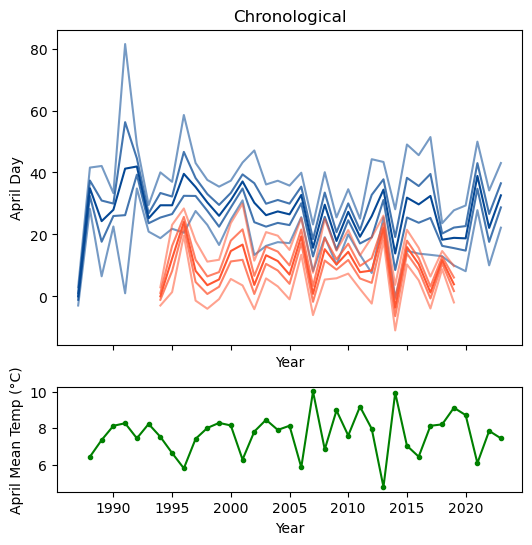

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(6, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

for perc in [5, 25, 50, 75, 95]:
    ax[0].plot(dict_percentiles_bb['year'], dict_percentiles_bb[perc], label=f'BB {perc}th percentile', 
             color="#054895", alpha=1 - (abs(50 - perc) / 100))
    ax[0].plot(dict_percentiles_moth['year'], dict_percentiles_moth[perc], label=f'Moth {perc}th percentile', 
             color="#FF5733", alpha=1 - (abs(50 - perc) / 100))
ax[0].set_xlabel('Year')
ax[0].set_ylabel('April Day')
ax[0].set_title('Chronological')

ax[1].plot(df_bb_data_april['year'], df_bb_data_april['temperature'], marker='.', color='green')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('April Mean Temp (°C)')

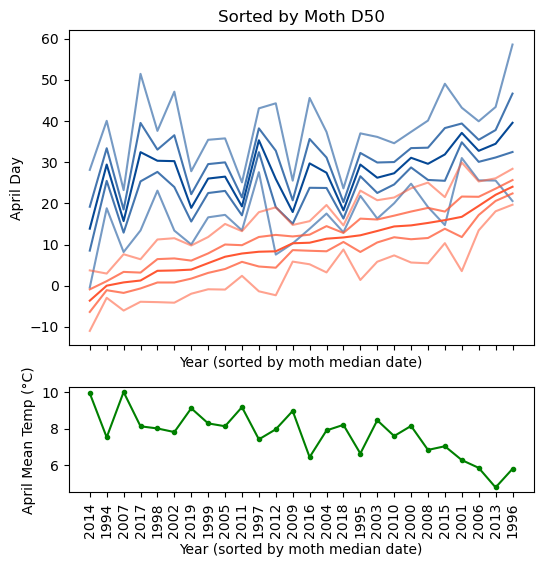

In [97]:
sorted_moth_inds = np.argsort(dict_percentiles_moth[50])
sorted_moth_years = np.array(dict_percentiles_moth['year'])[sorted_moth_inds]
sorted_bb_inds = [np.where(np.array(dict_percentiles_bb['year']) == yr)[0][0] for yr in sorted_moth_years]

fig, ax = plt.subplots(2, 1, figsize=(6, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
## plot percentiles over years sorted by moth median date
for perc in [5, 25, 50, 75, 95]:
    sorted_perc_tmp = np.array(dict_percentiles_moth[perc])[sorted_moth_inds]
    ax[0].plot(np.arange(len(sorted_perc_tmp)), sorted_perc_tmp, label=f'Moth {perc}th percentile', 
             color="#FF5733", alpha=1 - (abs(50 - perc) / 100))
    sorted_perc_tmp_bb = np.array(dict_percentiles_bb[perc])[sorted_bb_inds]
    ax[0].plot(np.arange(len(sorted_perc_tmp_bb)), sorted_perc_tmp_bb, label=f'BB {perc}th percentile', 
             color="#054895", alpha=1 - (abs(50 - perc) / 100))
    
ax[0].set_xlabel('Year (sorted by moth median date)')
ax[0].set_ylabel('April Day')
ax[0].set_xticks(ticks=np.arange(len(sorted_moth_years)))
ax[0].set_xticklabels(labels=sorted_moth_years, rotation=90)
ax[0].set_title('Sorted by Moth D50')

temp_data_sorted = df_bb_data_april.set_index('year').loc[sorted_moth_years]['temperature'].values
ax[1].plot(np.arange(len(temp_data_sorted)), temp_data_sorted, marker='.', color='green')
ax[1].set_xlabel('Year (sorted by moth median date)')
ax[1].set_ylabel('April Mean Temp (°C)')
ax[1].set_xticks(ticks=np.arange(len(sorted_moth_years)))
ax[1].set_xticklabels(labels=sorted_moth_years, rotation=90);

## Gone missing:
- Calculate 'gap' by subtracting D50_BB - D50_M. Plot as 3rd row. (Only use moth years, create a gapped arange to plot in correct years)
- Sorted by mean temp. Mean temp March -> moths. Mean temp April -> BB. Use both? Does gap/overlap change?


## Add;
- Not just gap but also overlap. (AUC of intersection?)
- Something a bit smarter than D50 difference. Per moth, we have a distr of BB. Eg sample 100 points/percentiles uniformly from moth, get BB distr for each, average.